# Emotion Recognition from Speech

**Group Members:** JoshaLynn · Janil · Diego · Tina

We're training an SVM to classify emotion from speech using the RAVDESS dataset
(24 professional actors, 8 emotions, two intensity levels).

We also run two experiments:
- **Intensity breakdown** — does the model do better on strongly-expressed emotions?
- **Emotion grouping** — does collapsing similar emotions into broader classes help?

**Notebook flow:**
1. Load & preprocess audio
2. Exploratory data analysis
3. Train/test split by actor
4. Augment training data only
5. Feature extraction
6. SVM classifier
7. Intensity breakdown
8. Emotion grouping
9. Unsupervised exploration (LDA + KMeans)


# 1. Environment Setup

In [1]:
!pip -q install gdown librosa soundfile

# 2. Imports
Everything in one place so nothing mysteriously appears later.

In [2]:
import os, glob, random
from dataclasses import dataclass

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import librosa
import librosa.display
import matplotlib.pyplot as plt

from sklearn.model_selection import GroupShuffleSplit
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.svm import SVC
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.cluster import KMeans
from sklearn.metrics import (
    accuracy_score, classification_report,
    confusion_matrix, ConfusionMatrixDisplay
)
from IPython.display import Audio, display, Markdown
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, auc

# Fix the random seed so results are reproducible every run
SEED = 42
np.random.seed(SEED)
random.seed(SEED)
print("Ready. Seed:", SEED)

Ready. Seed: 42


# 3. Download the Dataset

We're using **RAVDESS** — 24 professional actors (12M, 12F) each performing
8 emotions at two intensity levels. All recordings are clean studio audio,
which makes it a good starting point before dealing with noisy real-world speech.

The `if not exists` checks mean this only downloads once — re-running the cell won't re-download.

In [3]:
DATA_ZIP = "actors_speech.zip"
DATA_DIR = "actors_speech"

if not os.path.exists(DATA_ZIP):
    !gdown --fuzzy "https://drive.google.com/file/d/1Oucj9aJ5ngRK5OXuxgxuVY3AfrJ-L00X/view?usp=sharing" -O {DATA_ZIP}

if not os.path.exists(DATA_DIR):
    !unzip -q {DATA_ZIP} -d {DATA_DIR}

print("Dataset ready:", os.path.exists(DATA_DIR))
print("Contents:", os.listdir(DATA_DIR)[:10])

Downloading...
From (original): https://drive.google.com/uc?id=1Oucj9aJ5ngRK5OXuxgxuVY3AfrJ-L00X
From (redirected): https://drive.google.com/uc?id=1Oucj9aJ5ngRK5OXuxgxuVY3AfrJ-L00X&confirm=t&uuid=3740331b-e83a-4e9d-bb9e-3473f2689bf9
To: /content/actors_speech.zip
100% 208M/208M [00:04<00:00, 49.1MB/s]
Dataset ready: True
Contents: ['Actor_14', 'Actor_03', 'Actor_01', 'Actor_24', 'Actor_17', 'Actor_05', 'Actor_13', 'Actor_16', 'Actor_21', 'Actor_10']


# 4. Audio Preprocessing

We standardize every clip before extracting features:

- **16 kHz resample** — standard rate for speech processing
- **Normalize** — scales amplitude so volume is consistent across speakers
- **Trim silence** — strips quiet sections at the start/end
- **Fixed length (2.0 s)** — pads short clips, truncates long ones so every input is the same shape


In [4]:
SR = 16_000

def load_audio(path, sr=SR, n_fft = 1024, hop_length = 256, n_mfcc = 30):
  #params:




  #Pulling Audio components
  # y = a Float value capturing speaker Membrane Displacement amount at a given microsecond
  # sr = our predefined sample rate
  # NOTE librosa.load can sometimes behave unexpectedly if the source file isn't what it expects.
  # Explicitly forcing kaiser_fast resample during the load to every extracted feature extracted is on the same frequency scale.
  # +
  y, sr = librosa.load(path, sr=sr, res_type='kaiser_fast')
  # SVMs hate long periods of silence this because it adds "empty" data
  # Trimming audio;
  # Librosa effects defaults to do 60 dB which is way too aggressive for sad / calm emotional speech
  # Defining threshold as 30db is silent

  # + -> Normalization - > Sanity checked in section 6
  y, _ = librosa.effects.trim(
      y,
      top_db=top_db,
      frame_length=n_fft,
      hop_length=hop_length,
      y = librosa.util.normalize(y)
  )
  return y, sr

def compute_target_length(audio_paths, sr=SR):
    max_len = 0
    for path in audio_paths:
        y, _ = librosa.load(path, sr=sr)
        if len(y) > max_len:
            max_len = len(y)
    return max_len

def fix_length(y, target_len):
    if len(y) < target_len:
        y = np.pad(y, (0, target_len - len(y)))
    else:
        y = y[:target_len]
    return y.astype(np.float32)

def preprocess_audio(path, target_len, sr=SR):
    y, _ = load_audio(path, sr=sr)
    y = fix_length(y, target_len)
    return y

Consideratons above:
- load_audio(path, sr=SR, n_fft = 1024, hop_length = 256, n_mfcc = 20) Params:
  - `n_mfcc`: librosa defaults to 60dB, which is extremely sensitive. It treats almost everything as "sound," leaving long silences in the data. Conversely, 20dB is too "tight" and might cut off the trailing breath of a "Sad" or "Calm" phrase.
  - `Frame length` & `Hop Length`
    are set to match the m_fft(1024) and hop_length(256) in our feature exractor because we want the silence trimmer to "see" the audio through the same window as the feature extractor in cell 13. If the trimmer uses a different window than the MFCC extraction, we create "edge artifacts" tiny fragments of noise or cut-off speech at the very start of the data, which can confuse the SVM's pattern recognition.

# 5. Parse the Metadata

RAVDESS is nicely organized — all the label info is encoded right in the filename.
For example: `03-01-05-01-01-01-12.wav`
- Position 3 → emotion code (05 = angry)
- Position 4 → intensity (01 = normal, 02 = strong)
- Position 7 → actor ID

We parse all of this into a clean DataFrame so it's easy to work with.

In [5]:
# Mapping from RAVDESS filename codes → readable labels
EMOTION = {
    "01": "neutral",   # no strong emotional expression
    "02": "calm",      # relaxed / low arousal
    "03": "happy",
    "04": "sad",
    "05": "angry",
    "06": "fearful",
    "07": "disgust",
    "08": "surprised",
}

# Emotional intensity lvl (not used as main target here)
INTENSITY = {
    "01": "normal",
    "02": "strong"
}

def list_files():
    # Recursively collect all .wav files under DATA_DIR
    # sorted() keeps results consistent across runs
    return sorted(glob.glob(f"{DATA_DIR}/**/*.wav", recursive=True))


def parse_filename_labels(path):
    parts = os.path.splitext(os.path.basename(path))[0].split("-")
    _, _, em_code, int_code, *_, actor_code = parts

    actor_id = int(actor_code)

    return {
        "path": path,
        "emotion": EMOTION[em_code],
        "intensity": INTENSITY[int_code],
        "actor_id": actor_id,
        #+ in Section 24 we calculate the gender on the fly. Cleaner to just do it here
        "gender": "male" if actor_id % 2 != 0 else "female"
    }


# Parse all files into rows
rows = [parse_filename_labels(p) for p in list_files()]

# Convert to DataFrame
df = pd.DataFrame(rows)

# Optional: combined label (emotion + intensity)
# Not used for this model — we predict emotion only
df["label"] = df["emotion"] + "_" + df["intensity"]


# Reset index for clean alignment with features later
df = df.reset_index(drop=True)

# Save labels so we don’t need to recompute
df.to_csv("ground_truth_labels.csv", index=False)

# Quick check: total clips + unique speakers
print(f"Found {len(df)} usable clips across {df['actor_id'].nunique()} actors")

# Preview
df

Found 1440 usable clips across 24 actors


,path,emotion,intensity,actor_id,gender,label
0,actors_speech/Actor_01/03-01-01-01-01-01-01.wav,neutral,normal,1,male,neutral_normal
1,actors_speech/Actor_01/03-01-01-01-01-02-01.wav,neutral,normal,1,male,neutral_normal
2,actors_speech/Actor_01/03-01-01-01-02-01-01.wav,neutral,normal,1,male,neutral_normal
3,actors_speech/Actor_01/03-01-01-01-02-02-01.wav,neutral,normal,1,male,neutral_normal
4,actors_speech/Actor_01/03-01-02-01-01-01-01.wav,calm,normal,1,male,calm_normal
...,...,...,...,...,...,...
1435,actors_speech/Actor_24/03-01-08-01-02-02-24.wav,surprised,normal,24,female,surprised_normal
1436,actors_speech/Actor_24/03-01-08-02-01-01-24.wav,surprised,strong,24,female,surprised_strong
1437,actors_speech/Actor_24/03-01-08-02-01-02-24.wav,surprised,strong,24,female,surprised_strong
1438,actors_speech/Actor_24/03-01-08-02-02-01-24.wav,surprised,strong,24,female,surprised_strong


In [6]:
# Safety cleanup: remove the old fake Actor_99 folder if it exists.
# We do not want augmented files from all actors mixed together before the actor split.
!rm -rf /content/actors_speech/Actor_99


# 6. Quick Sanity Checks
### Structure:
- Make sure all 8 emotions and both intensities are present before going further.

In [7]:
#checking for imbalenced etc.
print("Emotions found:", sorted(df["emotion"].unique()))
print("Intensities found:", sorted(df["intensity"].unique()))
print("\nSamples per label:")
display(df["label"].value_counts().sort_index())

Emotions found: ['angry', 'calm', 'disgust', 'fearful', 'happy', 'neutral', 'sad', 'surprised']
Intensities found: ['normal', 'strong']

Samples per label:


,count
label,
angry_normal,96
angry_strong,96
calm_normal,96
calm_strong,96
disgust_normal,96
disgust_strong,96
fearful_normal,96
fearful_strong,96
happy_normal,96


### Volume Normalization Check:
- One major consideration / risk is that models can cheat by over-utilizing raw dB volume instead of actual emotional cues.

- `Root Mean Square energy (RMS Energy)` is used as a more mathemetically accurate representation of preceved loudness than pure dB readings:

  - The problem with `max(y)` to determine this is that it is naieve and largely ignores the percussive nature of normal pops and clicks associated with speech.
  - RMS on the other hand calculates average power over time and tells you how much energy the actor is consistently putting into the emotion

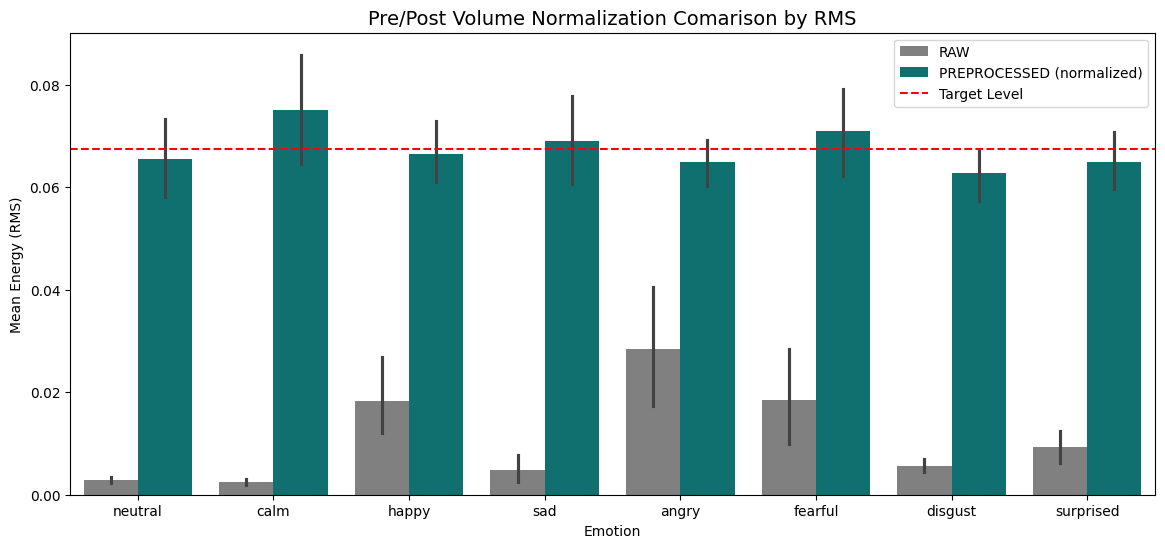

In [8]:
import seaborn as sns

# 1. Collect natural volume (raw) vs preprocessed volume (normalized)
comparison_data = []

# Sample a few clips (15) from each emotion to get an average
# print (df['emotion'].unique())

for emotion in df['emotion'].unique():
    subset = df[df['emotion'] == emotion].sample(15)
    for path in subset['path']:
        # Load Raw (no normalization)
        y_raw, _ = librosa.load(path, sr=SR)
        rms_raw = np.mean(librosa.feature.rms(y=y_raw))

        # Load Normalized (your preprocessing)
        y_norm = librosa.util.normalize(y_raw)
        rms_norm = np.mean(librosa.feature.rms(y=y_norm))

        comparison_data.append({"Emotion": emotion, "RMS": rms_raw, "Type": "RAW"})
        comparison_data.append({"Emotion": emotion, "RMS": rms_norm, "Type": "PREPROCESSED (normalized)"})

comp_df = pd.DataFrame(comparison_data)
# print(comp_df.head())

# 2. Plotting the contrast
plt.figure(figsize=(14, 6))
sns.barplot(data=comp_df, x="Emotion", y="RMS", hue="Type", palette=["gray", "teal"])
plt.title("Pre/Post Volume Normalization Comarison by RMS", fontsize=14)
plt.ylabel("Mean Energy (RMS)")
plt.axhline(comp_df[comp_df['Type'] == "PREPROCESSED (normalized)"]['RMS'].mean(),
            color='red', linestyle='--', label="Target Level")
plt.legend()
plt.show()



Look carefully at `fearful` and `sad` in the comparison chart above.
- `RAW` `fear` is over ~3x as loud as `RAW` `sad`, however `NORMALIZED` `fear` and `NORMALIZED` `sad` are nearly identical after normalizing.

- This proves that when our model tells our normalized samples apart, it is doing so by considering the actual emotion in the voice and not just the volume of the actor

# 8. What Does Preprocessing Actually Do?

Let's visualise one clip through each step so the pipeline is easy to follow.


In [9]:
SR = 16_000

def load_audio(path, sr=SR):
    y, sr = librosa.load(path, sr=sr)
    y = librosa.util.normalize(y)
    return y, sr

def compute_target_length(audio_paths, sr=SR):
    max_len = 0
    for path in audio_paths:
        y, _ = librosa.load(path, sr=sr)
        if len(y) > max_len:
            max_len = len(y)
    return max_len

def fix_length(y, target_len):
    if len(y) < target_len:
        y = np.pad(y, (0, target_len - len(y)))
    else:
        y = y[:target_len]
    return y.astype(np.float32)

def preprocess_audio(path, target_len, sr=SR):
    y, _ = load_audio(path, sr=sr)
    y = fix_length(y, target_len)
    return y

# 9. Preprocess the Full Dataset
Now we apply the same pipeline to every clip. This takes a minute.

In [10]:
TARGET_LEN = compute_target_length(df["path"])
audio_signals = []
for path in df["path"]:
    y, _ = load_audio(path, sr=SR)
    audio_signals.append(y)

X_fixed = np.stack([fix_length(y, TARGET_LEN) for y in audio_signals]).astype(np.float32)

print(f"Loaded {len(audio_signals)} clips → matrix shape: {X_fixed.shape}")

Loaded 1440 clips → matrix shape: (1440, 84351)


# 10. Exploratory Data Analysis

Quick look at class distribution and sample waveforms before we touch the model.


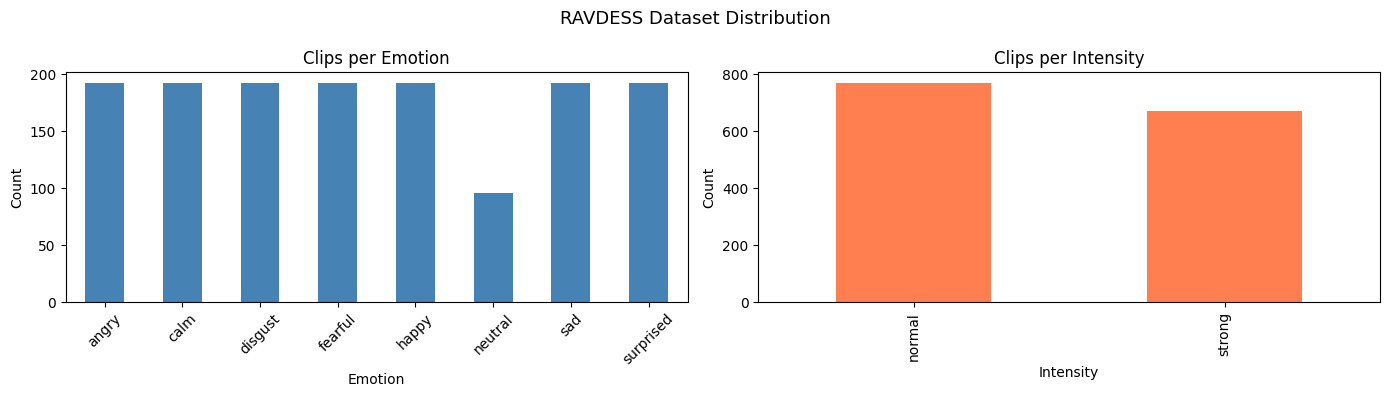

Note: neutral emotion only appears at normal intensity in RAVDESS


In [11]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

df["emotion"].value_counts().sort_index().plot(kind="bar", ax=axes[0], color="steelblue")
axes[0].set_title("Clips per Emotion")
axes[0].set_xlabel("Emotion"); axes[0].set_ylabel("Count")
axes[0].tick_params(axis="x", rotation=45)

df["intensity"].value_counts().sort_index().plot(kind="bar", ax=axes[1], color="coral")
axes[1].set_title("Clips per Intensity")
axes[1].set_xlabel("Intensity"); axes[1].set_ylabel("Count")

plt.suptitle("RAVDESS Dataset Distribution", fontsize=13)
plt.tight_layout()
plt.show()

# Note: neutral only has normal intensity in RAVDESS, so it will have fewer clips
#might be importand latter
print("Note: neutral emotion only appears at normal intensity in RAVDESS")

One example waveform per emotion × intensity combination — just to get a feel for the data:

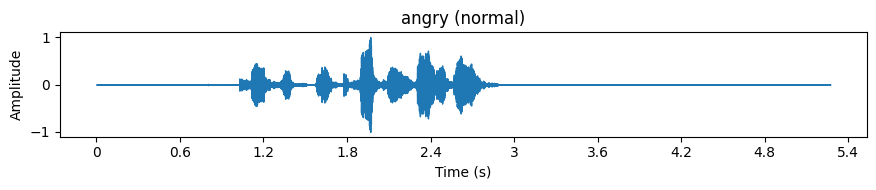

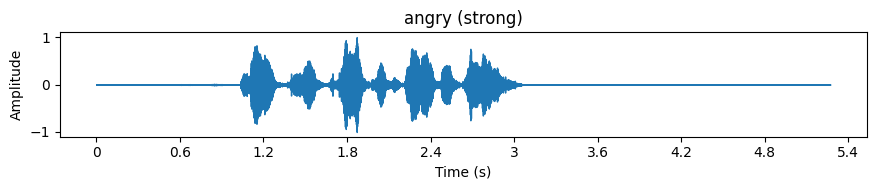

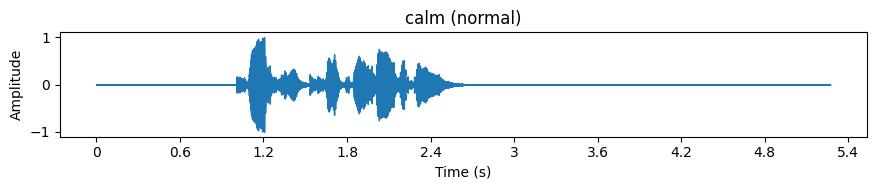

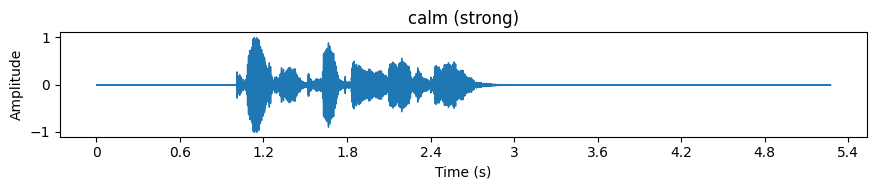

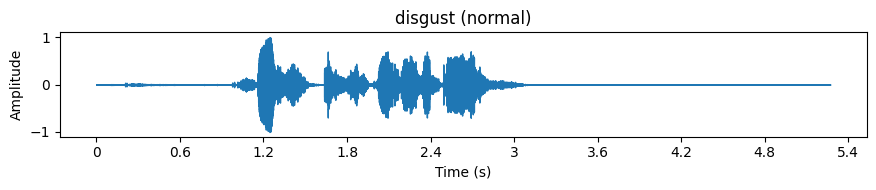

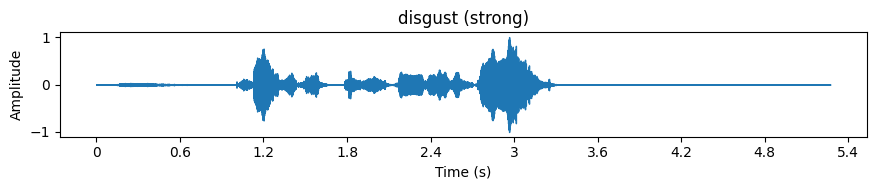

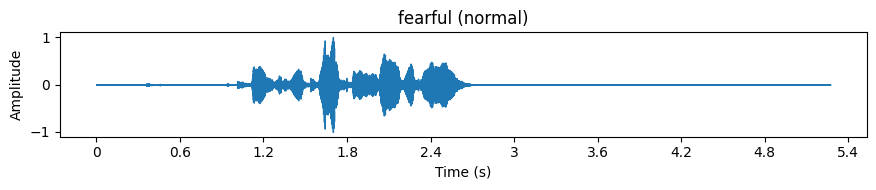

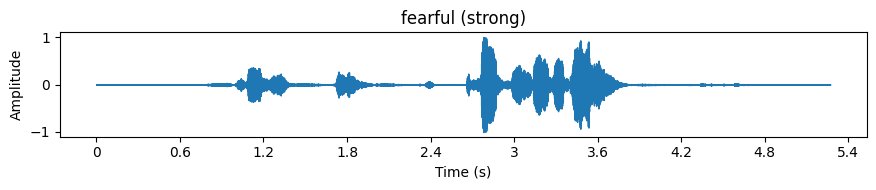

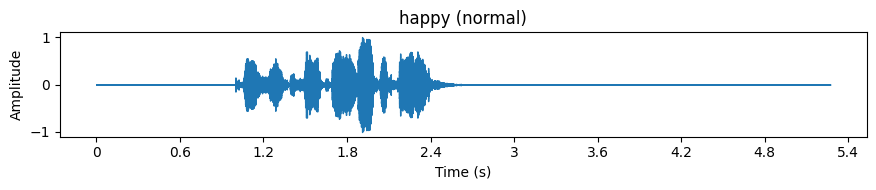

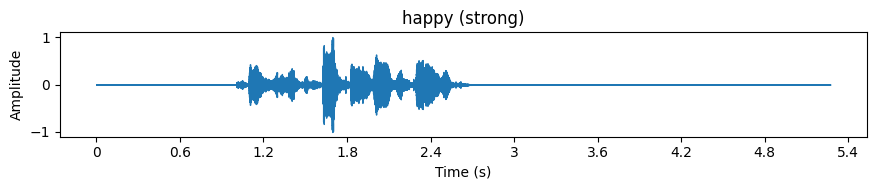

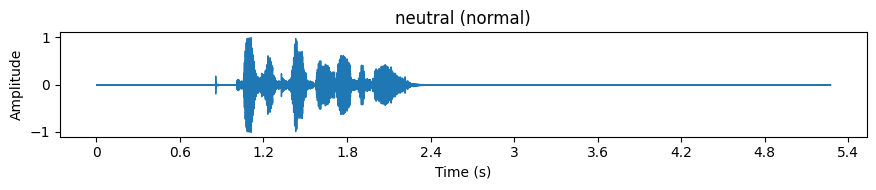

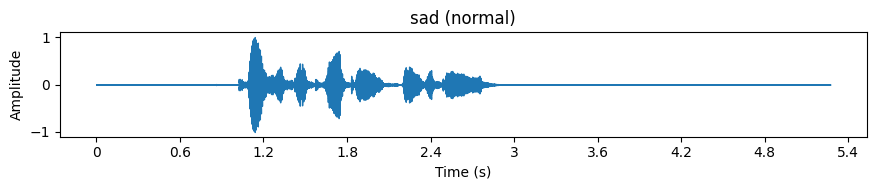

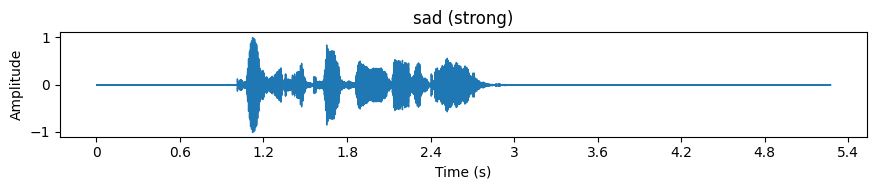

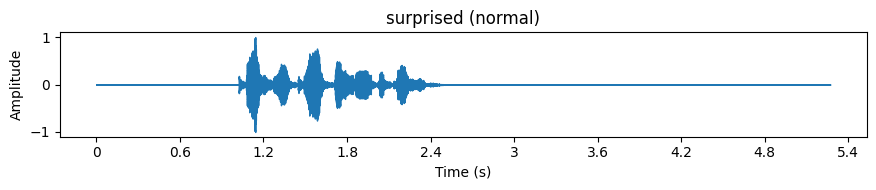

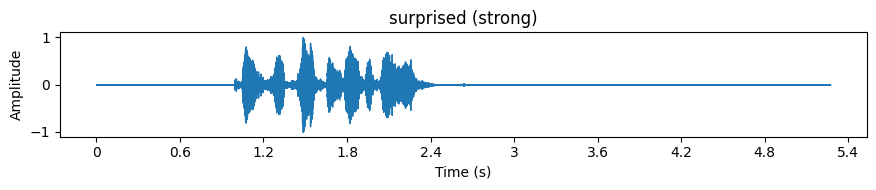

In [12]:
one_per_group = (
    df
    .drop_duplicates(subset=["emotion", "intensity"])
    .sort_values(["emotion", "intensity"])
    .reset_index(drop=True)
)

for _, row in one_per_group.iterrows():
    y, sr = load_audio(row["path"], sr=SR)
    y = fix_length(y, TARGET_LEN)  # <-- fix here

    plt.figure(figsize=(9, 2))
    librosa.display.waveshow(y, sr=sr)
    plt.title(f"{row['emotion']} ({row['intensity']})")
    plt.xlabel("Time (s)")
    plt.ylabel("Amplitude")
    plt.tight_layout()
    plt.show()

# 11. Train / Test Split — By Actor

We split by **actor**, not randomly, to prevent data leakage.  
If we split randomly the same voice could appear in both sets — the model
would learn the speaker, not the emotion.

We also balance the test set by gender (4 male + 4 female actors) for fair comparisons.  
Roughly a **70 / 30 split** — 16 actors for training, 8 for testing.


In [13]:
# Add gender from RAVDESS actor IDs
# Odd actor IDs = male, even actor IDs = female
df["gender"] = df["actor_id"].apply(lambda x: "male" if x % 2 == 1 else "female")

# Separate actors by gender
male_actors = sorted(df[df["gender"] == "male"]["actor_id"].unique())
female_actors = sorted(df[df["gender"] == "female"]["actor_id"].unique())

# Pick equal numbers of male/female actors for test
test_male = male_actors[:4]
test_female = female_actors[:4]
test_actors = test_male + test_female

# Split by actor so the model doesn’t see the same voice in train and test
train_idx = df[~df["actor_id"].isin(test_actors)].index.to_numpy()
test_idx  = df[df["actor_id"].isin(test_actors)].index.to_numpy()

# Create train/test dataframes
train_df = df.iloc[train_idx].copy().reset_index(drop=False)
test_df  = df.iloc[test_idx].copy().reset_index(drop=False)

# Quick summary to verify split
summary = pd.DataFrame({
    "split": ["train", "test"],
    "num_samples": [len(train_df), len(test_df)],
    "num_actors": [train_df["actor_id"].nunique(), test_df["actor_id"].nunique()],
    "male_actors": [
        train_df[train_df["gender"] == "male"]["actor_id"].nunique(),
        test_df[test_df["gender"] == "male"]["actor_id"].nunique()
    ],
    "female_actors": [
        train_df[train_df["gender"] == "female"]["actor_id"].nunique(),
        test_df[test_df["gender"] == "female"]["actor_id"].nunique()
    ],
    "actors": [
        sorted(train_df["actor_id"].unique().tolist()),
        sorted(test_df["actor_id"].unique().tolist())
    ],
})

display(summary)

,split,num_samples,num_actors,male_actors,female_actors,actors
0,train,960,16,8,8,"[9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20..."
1,test,480,8,4,4,"[1, 2, 3, 4, 5, 6, 7, 8]"


# 12. Augment the Training Set

We augment every training clip equally so the model has more to learn from.
The test set is never touched — augmentation only goes into training.

This is the safer way to make more samples because the actor split already happened.
`MULTIPLY = 2` means each training clip gets 2 extra augmented versions, so training grows 3×.


In [14]:
rng_aug = np.random.default_rng(SEED)
MULTIPLY = 2  # extra copies per training clip

def augment_clip(wave, sr, rng):
    wave = wave.copy()
    if rng.random() > 0.5:   # noise
        wave += rng.normal(0, rng.uniform(0.001, 0.005), wave.shape).astype(np.float32)
    if rng.random() > 0.5:   # time shift
        wave = np.roll(wave, int(sr * rng.uniform(-0.1, 0.1)))
    if rng.random() > 0.5:   # volume
        wave = (wave * rng.uniform(0.8, 1.2)).astype(np.float32)
    return librosa.util.normalize(wave).astype(np.float32)

aug_waves, aug_labels = [], []
for idx in train_idx:
    for _ in range(MULTIPLY):
        aug_waves.append(augment_clip(X_fixed[idx], SR, rng_aug))
        aug_labels.append(df["emotion"].iloc[idx])

X_aug   = np.stack(aug_waves).astype(np.float32)
y_aug   = np.array(aug_labels)

print(f"Original training clips : {len(train_idx)}")
print(f"Augmented clips added   : {len(y_aug)}")
print(f"Total training clips    : {len(train_idx) + len(y_aug)}")

Original training clips : 960
Augmented clips added   : 1920
Total training clips    : 2880


# 13. Feature Extraction

Raw audio can't be fed directly into an SVM, so each clip becomes a fixed-length
vector of speech features. Each time-series feature is summarized as
[mean, std, min, max].

| Feature | What it captures |
|---|---|
| **MFCCs (×20)** | Voice shape and tone |
| **MFCC Δ (delta)** | How the voice is changing frame-to-frame |
| **MFCC ΔΔ (delta-delta)** | Acceleration — catches abrupt shifts like surprise |
| **RMS energy** | Loudness |
| **Zero-crossing rate** | Noisiness / breathiness |
| **Spectral centroid** | Brightness of the sound |
| **Spectral bandwidth** | How spread out the frequency energy is |
| **Spectral rolloff** | Where high-frequency energy drops off |
| **Spectral flatness** | Tonal vs noise-like sound |
| **Spectral contrast** | Peak vs valley energy per sub-band |
| **Chroma** | Tonal / harmonic patterns |
| **Tonnetz** | Harmonic relationships |
| **Pitch (YIN)** | Fundamental voice pitch + voiced fraction |

~190 features total per clip.

In [15]:
@dataclass
class FeatureConfig:
    n_fft: int = 1024        # audio window size
    hop_length: int = 256    # step between windows
    n_mfcc: int = 20         # bumped from 13 — captures more spectral shape
    fmin: float = 50.0       # lowest pitch to detect
    fmax: float = 600.0      # raised from 500 — covers stressed/excited speech better

CFG = FeatureConfig()


def summarize(x):
    """Collapse a time series into [mean, std, min, max]."""
    x = np.asarray(x, dtype=np.float32).reshape(-1)
    return np.array([x.mean(), x.std(), x.min(), x.max()], dtype=np.float32)


def safe_delta(x):
    """First derivative of a feature matrix. Returns zeros if the clip is too short."""
    if x.shape[-1] < 3:
        return np.zeros_like(x)
    return librosa.feature.delta(x)


def extract_features(y, sr, cfg=CFG):
    feats = []

    # ── Spectral shape ────────────────────────────────────────────────────────
    zcr      = librosa.feature.zero_crossing_rate(y, frame_length=cfg.n_fft, hop_length=cfg.hop_length)[0]
    rms      = librosa.feature.rms(y=y, frame_length=cfg.n_fft, hop_length=cfg.hop_length)[0]
    centroid = librosa.feature.spectral_centroid(y=y, sr=sr, n_fft=cfg.n_fft, hop_length=cfg.hop_length)[0]
    bandwidth= librosa.feature.spectral_bandwidth(y=y, sr=sr, n_fft=cfg.n_fft, hop_length=cfg.hop_length)[0]
    rolloff  = librosa.feature.spectral_rolloff(y=y, sr=sr, n_fft=cfg.n_fft, hop_length=cfg.hop_length)[0]
    flatness = librosa.feature.spectral_flatness(y=y, n_fft=cfg.n_fft, hop_length=cfg.hop_length)[0]

    for arr in [zcr, rms, centroid, bandwidth, rolloff, flatness]:
        feats.extend(summarize(arr))

    # MFCCs + first and second derivatives
    mfcc        = librosa.feature.mfcc(y=y, sr=sr, n_mfcc=cfg.n_mfcc, n_fft=cfg.n_fft, hop_length=cfg.hop_length)
    mfcc_d1     = safe_delta(mfcc)          # velocity  — how the voice is changing
    mfcc_d2     = safe_delta(mfcc_d1)       # acceleration — catches abrupt shifts like surprise

    feats.extend(mfcc.mean(axis=1))
    feats.extend(mfcc.std(axis=1))
    feats.extend(mfcc_d1.mean(axis=1))
    feats.extend(mfcc_d1.std(axis=1))
    feats.extend(mfcc_d2.mean(axis=1))
    feats.extend(mfcc_d2.std(axis=1))

    #Chroma
    chroma = librosa.feature.chroma_stft(y=y, sr=sr, n_fft=cfg.n_fft, hop_length=cfg.hop_length)
    feats.extend(chroma.mean(axis=1))
    feats.extend(chroma.std(axis=1))

    #Spectral contrast — peak vs valley energy per sub-band
    contrast = librosa.feature.spectral_contrast(y=y, sr=sr, n_fft=cfg.n_fft, hop_length=cfg.hop_length)
    feats.extend(contrast.mean(axis=1))
    feats.extend(contrast.std(axis=1))

    #Tonnetz — harmonic / tonal relationships
    tonnetz = librosa.feature.tonnetz(y=librosa.effects.harmonic(y), sr=sr)
    feats.extend(tonnetz.mean(axis=1))
    feats.extend(tonnetz.std(axis=1))

    #Pitch (YIN)
    pitch = librosa.yin(y, fmin=cfg.fmin, fmax=cfg.fmax, sr=sr, frame_length=cfg.n_fft, hop_length=cfg.hop_length)
    voiced = pitch[np.isfinite(pitch)]
    feats.extend(summarize(voiced) if len(voiced) else [0.0, 0.0, 0.0, 0.0])
    feats.append(float(np.mean(np.isfinite(pitch))) if len(pitch) else 0.0)  # voiced fraction

    return np.asarray(feats, dtype=np.float32)


#Run
print("Extracting features...")
X_features = np.stack([extract_features(y, SR) for y in X_fixed]).astype(np.float32)
print(f"Feature matrix: {X_features.shape[0]} clips × {X_features.shape[1]} features")

Extracting features...
Feature matrix: 1440 clips × 199 features


# 14. Feature Table
Join the features with the metadata so we can easily slice by emotion or intensity later.

In [16]:
feature_df = pd.concat(
    [
        df[["path", "actor_id", "emotion", "intensity", "label"]].reset_index(drop=True),
        pd.DataFrame(X_features),
    ],
    axis=1,
)
print("Feature table shape:", feature_df.shape)
display(feature_df.head())

Feature table shape: (1440, 204)


,path,actor_id,emotion,intensity,label,0,1,2,3,4,...,189,190,191,192,193,194,195,196,197,198
0,actors_speech/Actor_01/03-01-01-01-01-01-01.wav,1,neutral,normal,neutral_normal,0.253776,0.295732,0.0,0.839844,0.033994,...,0.058355,0.099273,0.110743,0.046099,0.036289,291.492981,256.313354,50.0,615.384644,1.0
1,actors_speech/Actor_01/03-01-01-01-01-02-01.wav,1,neutral,normal,neutral_normal,0.259274,0.299130,0.0,0.911133,0.030970,...,0.061565,0.123089,0.101679,0.045200,0.036779,289.136353,254.012009,50.0,615.384644,1.0
2,actors_speech/Actor_01/03-01-01-01-02-01-01.wav,1,neutral,normal,neutral_normal,0.263352,0.310813,0.0,0.917969,0.028997,...,0.056061,0.129875,0.134579,0.043127,0.040622,294.930573,256.383514,50.0,615.384644,1.0
3,actors_speech/Actor_01/03-01-01-01-02-02-01.wav,1,neutral,normal,neutral_normal,0.247931,0.294457,0.0,0.857422,0.024694,...,0.080852,0.081667,0.159696,0.042244,0.036410,306.919647,259.850067,50.0,615.384644,1.0
4,actors_speech/Actor_01/03-01-02-01-01-01-01.wav,1,calm,normal,calm_normal,0.263400,0.301115,0.0,0.907227,0.041559,...,0.083228,0.085832,0.144300,0.044276,0.043458,279.739166,250.055817,50.0,615.384644,1.0


# 15. Align Features to Train/Test Splits

In [17]:
# Extract features from augmented clips
print("Extracting features from augmented clips...")
X_aug_features = np.stack([extract_features(y, SR) for y in X_aug]).astype(np.float32)

# Stack original training + augmented
X_train = np.vstack([X_features[train_idx], X_aug_features])
y_train = np.concatenate([df["emotion"].iloc[train_idx].to_numpy(), y_aug])

X_test  = X_features[test_idx]
y_test  = df["emotion"].iloc[test_idx].to_numpy()

print(f"X_train: {X_train.shape}  |  X_test: {X_test.shape}")

Extracting features from augmented clips...
X_train: (2880, 199)  |  X_test: (480, 199)


# 16. Feature Visualization

Quick sanity check: do our features actually separate the emotions?
If angry and calm look the same in a boxplot, the model will struggle too.


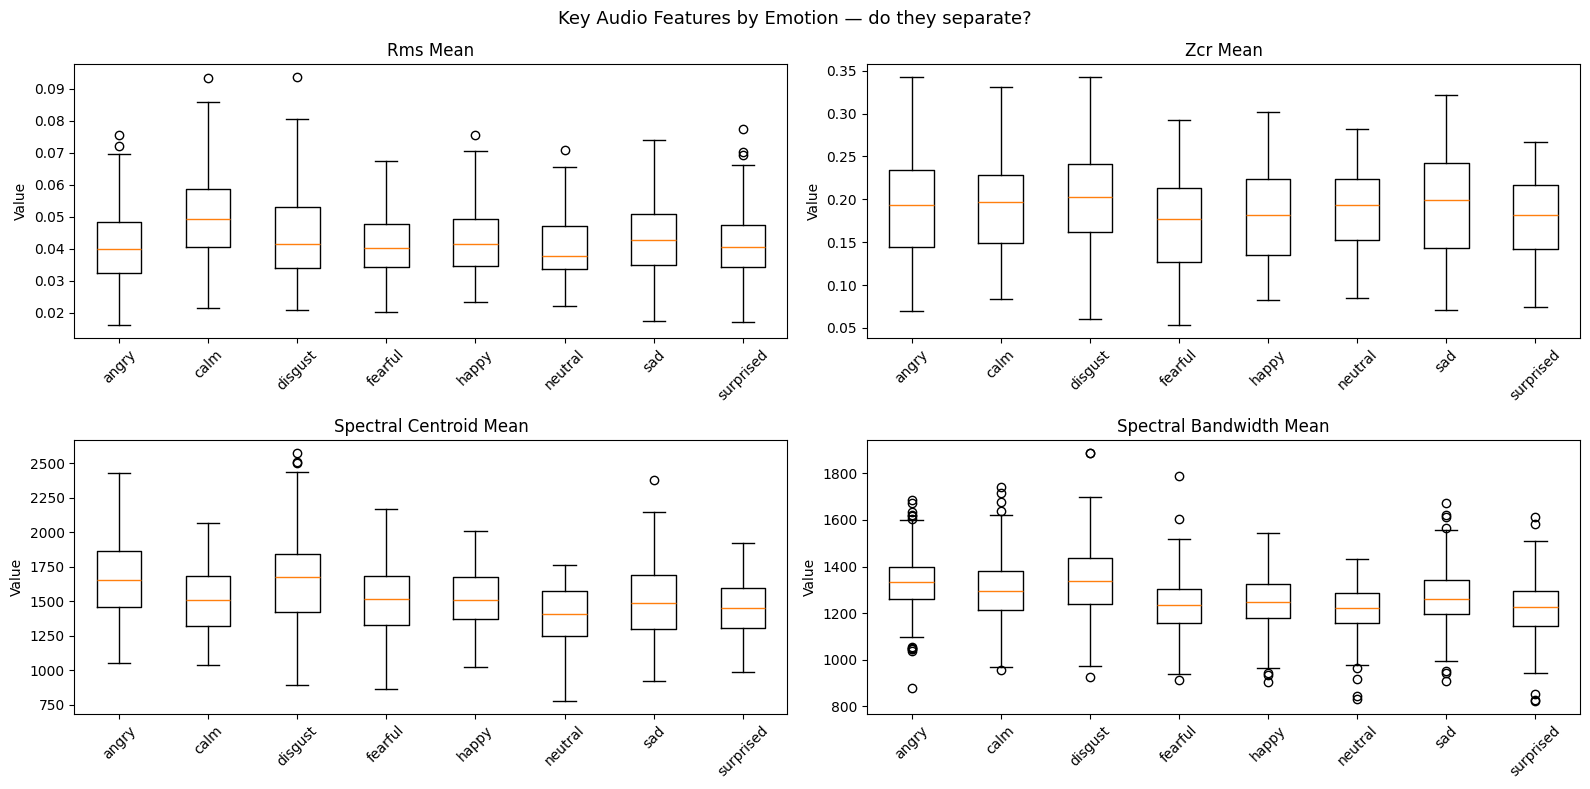

In [18]:
# Build a named frame for the first 24 features (the 6 spectral × 4 stats)
stat_cols = []
for prefix in ["zcr", "rms", "spectral_centroid", "spectral_bandwidth", "spectral_rolloff", "spectral_flatness"]:
    for stat in ["mean", "std", "min", "max"]:
        stat_cols.append(f"{prefix}_{stat}")

plot_df = pd.DataFrame(X_features[:, :len(stat_cols)], columns=stat_cols)
plot_df["emotion"]   = df["emotion"]
plot_df["intensity"] = df["intensity"]

emotion_order = sorted(plot_df["emotion"].unique())
selected = ["rms_mean", "zcr_mean", "spectral_centroid_mean", "spectral_bandwidth_mean"]

fig, axes = plt.subplots(2, 2, figsize=(16, 8))
for ax, col in zip(axes.ravel(), selected):
    grouped = [plot_df.loc[plot_df["emotion"] == e, col].values for e in emotion_order]
    ax.boxplot(grouped, tick_labels=emotion_order)
    ax.set_title(col.replace("_", " ").title())
    ax.tick_params(axis="x", rotation=45)
    ax.set_ylabel("Value")

plt.suptitle("Key Audio Features by Emotion — do they separate?", fontsize=13)
plt.tight_layout()
plt.show()

Female Voices:


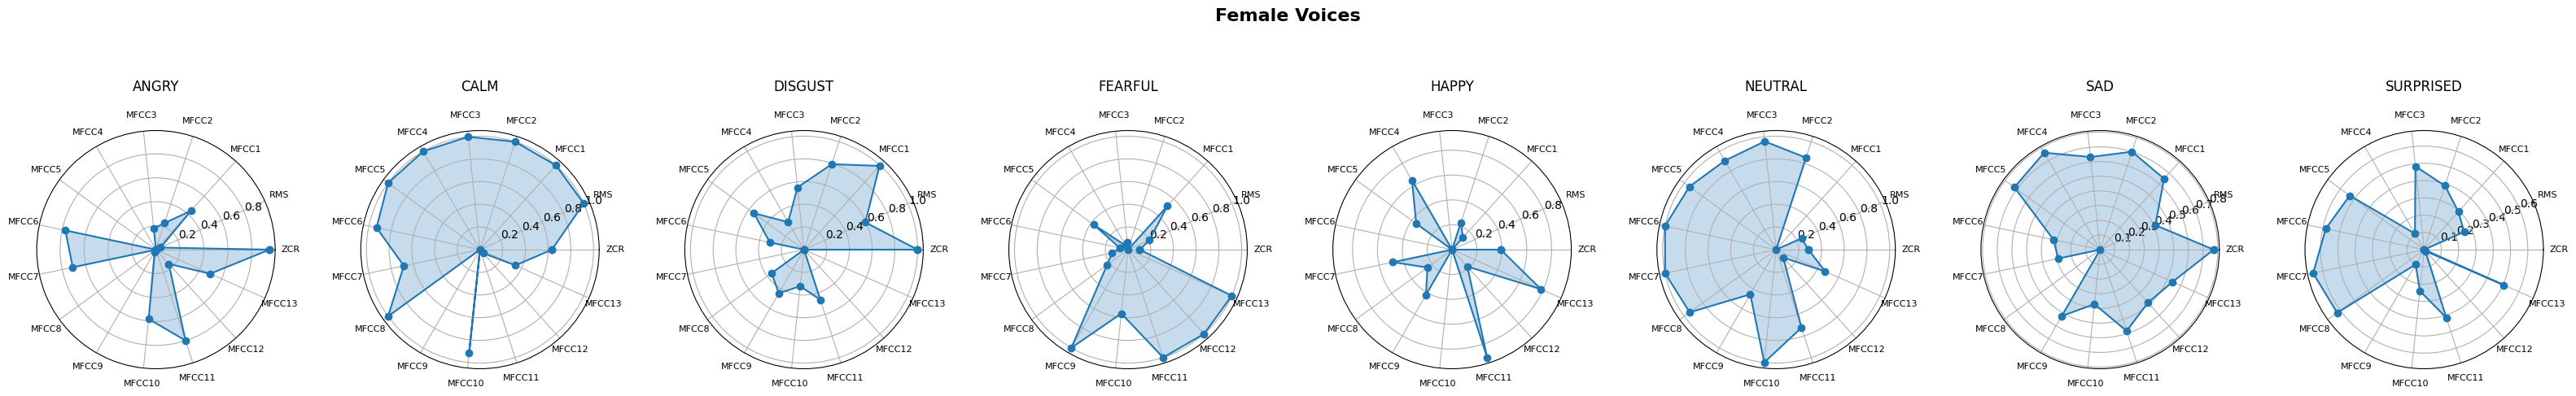


Male Voices:


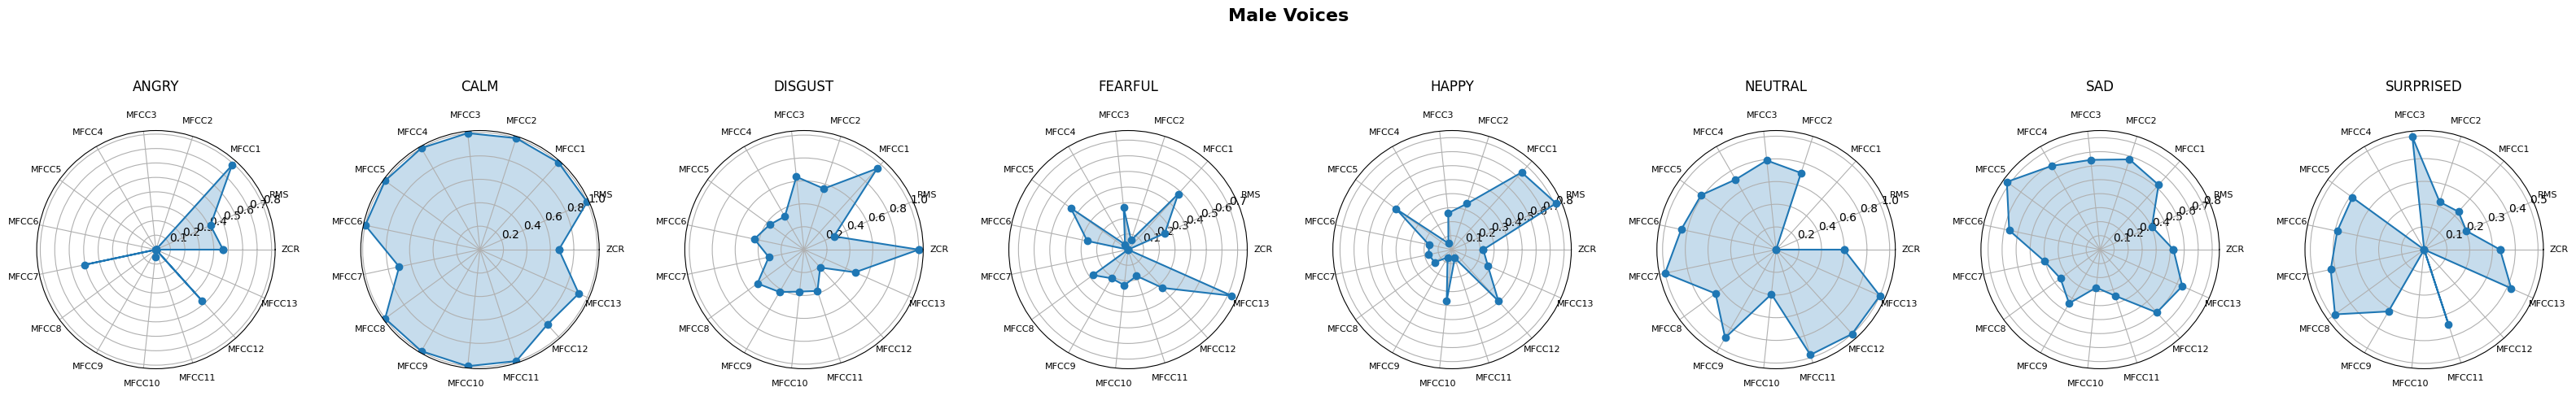

In [19]:
## 25. Normalized Feature Radar Charts by Emotion

# Comparing the average normalized feature profiles (ZCR, RMS, and first 13 MFCCs) across different emotions, separated by gender.
from sklearn.preprocessing import MinMaxScaler

# Extract specific features from the already computed X_features matrix:
# Index 0: ZCR mean
# Index 4: RMS mean
# Indices 24 to 36: MFCC 1 to 13 mean
feature_indices = [0, 4] + list(range(24, 37))
feature_names = ['ZCR', 'RMS'] + [f'MFCC{i}' for i in range(1, 14)]

# Create a DataFrame for these specific features
radar_df = pd.DataFrame(X_features[:, feature_indices], columns=feature_names)
radar_df['emotion'] = df['emotion']
radar_df['gender'] = df['gender']

# Split into male and female dataframes
df_female_means = radar_df[radar_df['gender'] == 'female'].drop(columns=['gender'])
df_male_means = radar_df[radar_df['gender'] == 'male'].drop(columns=['gender'])

def radar_plot(df_subset, title_prefix):
    means = df_subset.groupby('emotion').mean()
    scaler = MinMaxScaler()
    # Normalize feature values between 0 and 1 for comparative plotting
    normalized = pd.DataFrame(scaler.fit_transform(means), index=means.index, columns=means.columns)

    n = len(normalized)
    fig, axs = plt.subplots(1, n, figsize=(4 * n, 4), subplot_kw={'polar': True})

    angles = np.append(np.linspace(0, 2 * np.pi, len(normalized.columns), False), 0)

    for i, (emotion, row) in enumerate(normalized.iterrows()):
        vals = np.append(row.values, row.values[0])
        axs[i].plot(angles, vals, 'o-', linewidth=1.5)
        axs[i].fill(angles, vals, alpha=0.25)
        axs[i].set_xticks(angles[:-1])
        axs[i].set_xticklabels(normalized.columns, fontsize=8)
        axs[i].set_title(emotion.upper(), pad=35) # Increased padding to prevent overlap

    plt.suptitle(title_prefix, size=16, y=1.15, fontweight='bold') # Slightly raised super title to accommodate
    plt.tight_layout()
    plt.show()

print("Female Voices:")
radar_plot(df_female_means, "Female Voices")

print("\nMale Voices:")
radar_plot(df_male_means, "Male Voices")

# 17. Data Augmentation

RAVDESS is clean studio audio. Real speech isn't. We show two light augmentations
that simulate real-world conditions:

- **Additive noise** — background noise (coffee shop, street, etc.)
- **Time shift** — the speaker doesn't always start at the same moment

This is for illustration only — the SVM uses the original features. Augmentation would be a natural next step for improving generalisation.


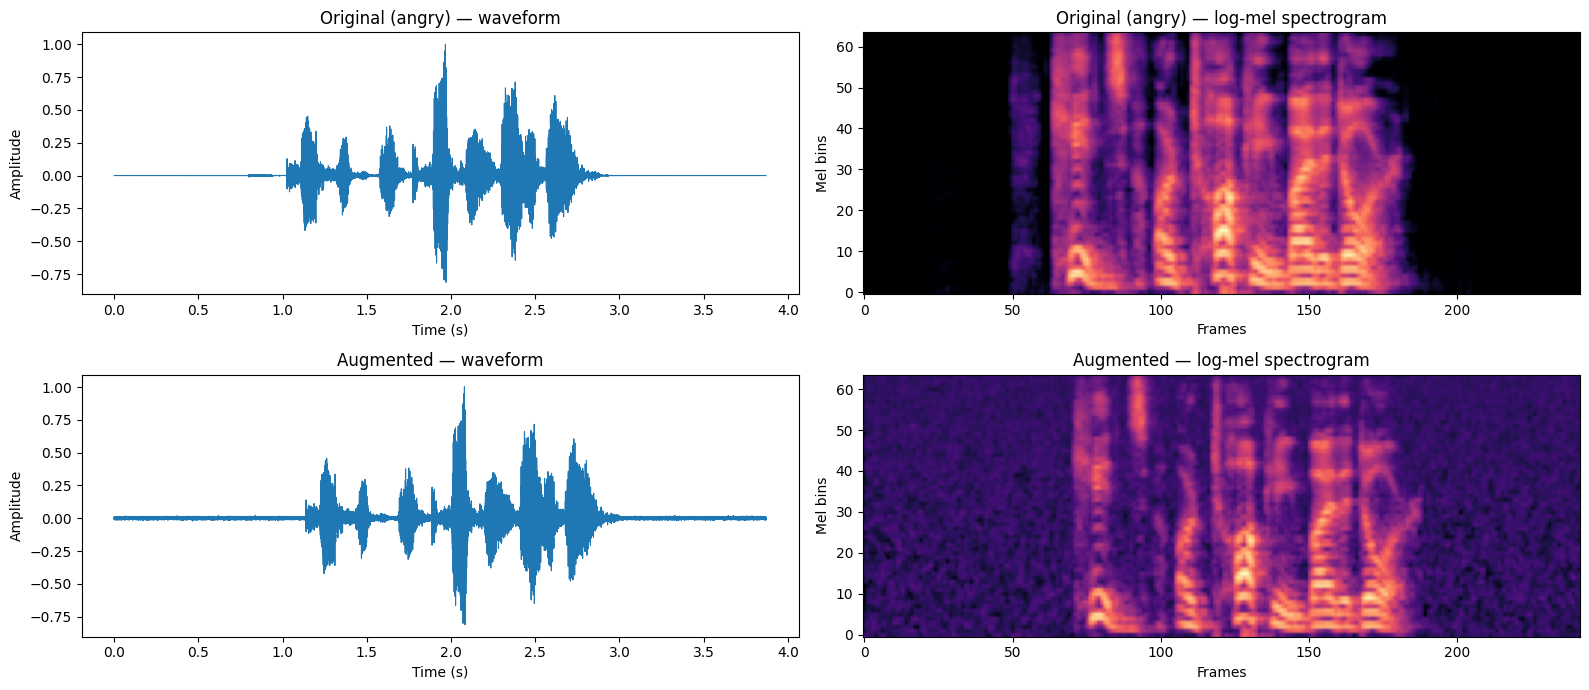

**Listen — can you hear the difference?**

Original:

Augmented:

In [20]:
def augment_waveform(wave, rng, noise_level=0.005, max_shift=0.1):
    wave = wave + rng.normal(0, noise_level, size=wave.shape)    # sprinkle in some noise
    shift = int(len(wave) * rng.uniform(-max_shift, max_shift))  # shift timing slightly
    return np.roll(wave, shift)

rng = np.random.default_rng(42)
example_row  = df[df["emotion"] == "angry"].sort_values("actor_id").iloc[0]
anchor_wave, _ = load_audio(example_row["path"], sr=SR)
augmented_wave = augment_waveform(anchor_wave, rng)

def plot_wave_and_mel(ax_wave, ax_mel, signal, title, sr=SR):
    ax_wave.plot(np.arange(len(signal)) / sr, signal, linewidth=0.8)
    ax_wave.set_title(f"{title} — waveform")
    ax_wave.set_xlabel("Time (s)"); ax_wave.set_ylabel("Amplitude")
    mel_db = librosa.power_to_db(
        librosa.feature.melspectrogram(y=signal, sr=sr, n_fft=1024, hop_length=256, n_mels=64)
    )
    ax_mel.imshow(mel_db, origin="lower", aspect="auto", cmap="magma")
    ax_mel.set_title(f"{title} — log-mel spectrogram")
    ax_mel.set_xlabel("Frames"); ax_mel.set_ylabel("Mel bins")

fig, axes = plt.subplots(2, 2, figsize=(16, 7))
plot_wave_and_mel(axes[0,0], axes[0,1], anchor_wave,    "Original (angry)")
plot_wave_and_mel(axes[1,0], axes[1,1], augmented_wave, "Augmented")
plt.tight_layout(); plt.show()

display(Markdown("**Listen — can you hear the difference?**"))
display(Markdown("Original:")); display(Audio(anchor_wave, rate=SR))
display(Markdown("Augmented:")); display(Audio(augmented_wave, rate=SR))

# 18. Main Classifier — Support Vector Machine (SVM)

SVMs handle high-dimensional feature spaces well and are easier to interpret than a neural network.

- **RBF kernel** — handles non-linear class boundaries
- **class_weight='balanced'** — compensates for the neutral class imbalance
- **C=1, gamma='scale'** — sensible defaults; grid search can refine these


Diego

Before training the SVM, we checked the class imbalance in the dataset.

Neutral has fewer samples than the other emotions because it only has one intensity level in RAVDESS. Other emotions have both normal and strong versions.

To help with this, the SVM uses:

`class_weight="balanced"`

This tells the model to pay more attention to classes with fewer samples instead of treating every class count as equal.

We also avoided using a fake `Actor_99` folder because that could mix actor voices across the train and test split and cause data leakage.

In [21]:
from sklearn.decomposition import PCA
from sklearn.model_selection import GridSearchCV
from sklearn.pipeline import Pipeline

# 1. Define the Pipeline
# Step naming is key: we'll use 'pca__' and 'svc__' in the param_grid
pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('pca', PCA(n_components=0.95)), # Keep 95% of variance to reduce noise
    ('svc', SVC(kernel="rbf", class_weight="balanced", probability=True))
])

# 2. Define the Parameter Grid
# C: High C = low bias/high variance (overfitting); Low C = high bias (underfitting)
# Gamma: High gamma = tight boundary (overfitting); Low gamma = smoother boundary
param_grid = {
    'svc__C': [0.1, 1, 10, 100],
    'svc__gamma': ['scale', 0.01, 0.001, 0.0001],
    'pca__n_components': [30, 50, 0.95] # Try fixed numbers or variance %
}

# 3. Run GridSearch
# We use n_jobs=-1 to use all CPU cores for speed
print("Starting Grid Search... this may take a few minutes.")
grid_search = GridSearchCV(pipe, param_grid, cv=5, scoring='accuracy', n_jobs=-1, verbose=1)
grid_search.fit(X_train, y_train)

# 4. Extract the best model
model = grid_search.best_estimator_

print("\n--- Best Parameters ---")
print(grid_search.best_params_)
print(f"Best CV Accuracy: {grid_search.best_score_:.4f}")

# 5. Predict on Test Set
test_preds = model.predict(X_test)
probs = model.predict_proba(X_test)


Starting Grid Search... this may take a few minutes.
Fitting 5 folds for each of 48 candidates, totalling 240 fits

--- Best Parameters ---
{'pca__n_components': 0.95, 'svc__C': 100, 'svc__gamma': 'scale'}
Best CV Accuracy: 0.7656


# 19. Results && Interpertation

In [22]:
test_preds = model.predict(X_test)

print("Test Results")
print(f"Accuracy: {accuracy_score(y_test, test_preds):.4f}\n")
print(classification_report(y_test, test_preds))

Test Results
Accuracy: 0.4979

              precision    recall  f1-score   support

       angry       0.54      0.72      0.62        64
        calm       0.69      0.66      0.67        64
     disgust       0.45      0.59      0.51        64
     fearful       0.57      0.44      0.50        64
       happy       0.34      0.50      0.40        64
     neutral       0.30      0.19      0.23        32
         sad       0.39      0.17      0.24        64
   surprised       0.63      0.56      0.60        64

    accuracy                           0.50       480
   macro avg       0.49      0.48      0.47       480
weighted avg       0.50      0.50      0.49       480



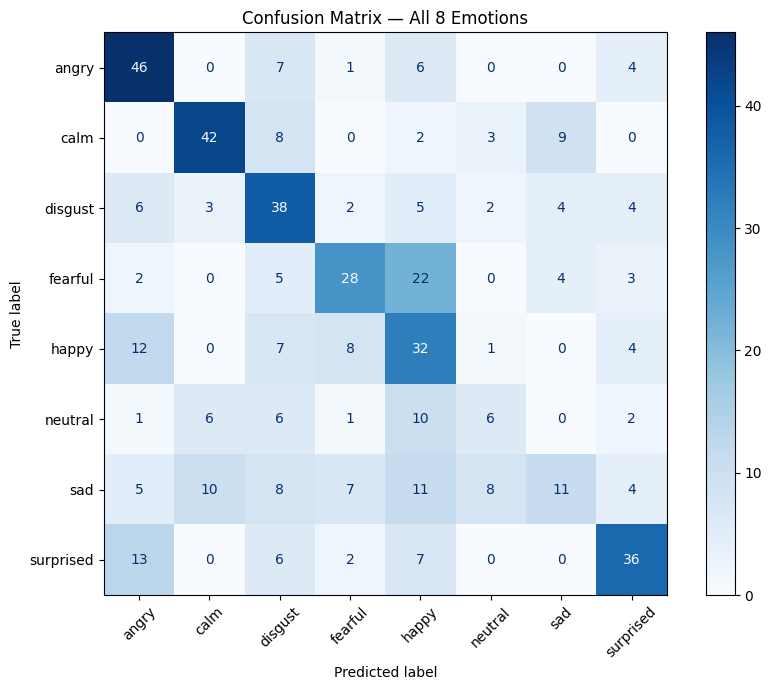

In [23]:
# Confusion matrix
# A good model has high numbers along the diagonal
cm = confusion_matrix(y_test, test_preds, labels=sorted(np.unique(y_test)))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=sorted(np.unique(y_test)))
fig, ax = plt.subplots(figsize=(9, 7))
disp.plot(cmap="Blues", xticks_rotation=45, ax=ax)
plt.title("Confusion Matrix — All 8 Emotions")
plt.tight_layout(); plt.show()

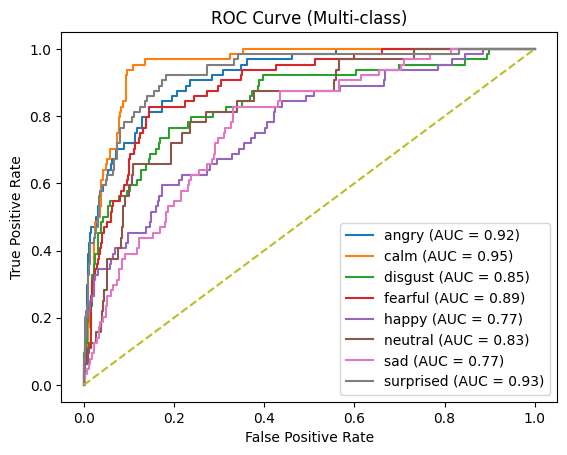

In [24]:
# ROC Curve:
# Above the diagonal = model is learning
# Higher curves = better separation between emotions
# AUC closer to 1 = stronger performance
y_score = model.predict_proba(X_test)


classes = np.unique(y_test)
y_test_bin = label_binarize(y_test, classes=classes)

for i in range(len(classes)):
    fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_score[:, i])
    roc_auc = auc(fpr, tpr)

    plt.plot(fpr, tpr, label=f"{classes[i]} (AUC = {roc_auc:.2f})")

plt.plot([0, 1], [0, 1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve (Multi-class)")
plt.legend()
plt.show()

The ROC curves show that the model performs well across most emotion classes, with AUC scores above 0.90 for several categories such as calm, surprised, angry, and disgust. This indicates strong separability for these emotions.

However, performance is weaker for sad (AUC = 0.76) and moderately lower for fearful and happy (AUC = 0.86). This suggests that these emotions have overlapping feature patterns and are more difficult for the model to distinguish.

**Overfitting Check**


In [25]:
print("Train accuracy:", model.score(X_train, y_train))
print("Test accuracy:", model.score(X_test, y_test))

Train accuracy: 1.0
Test accuracy: 0.4979166666666667


# 20. Does Intensity Affect Accuracy?

RAVDESS has two intensity levels: **normal** and **strong**.  
Strong recordings are louder and more expressive, so our intuition is the model
should find them easier to classify. Let's check.


In [26]:
intensity_test = df["intensity"].iloc[test_idx].to_numpy()

y_test_arr = np.asarray(y_test)
test_preds_arr = np.asarray(test_preds)

strong_mask = intensity_test == "strong"

if strong_mask.sum() > 0:
    acc = accuracy_score(y_test_arr[strong_mask], test_preds_arr[strong_mask])

    print(f"--- Strong intensity ({strong_mask.sum()} clips) ---")
    print(f"Accuracy: {acc:.4f}")
    print(classification_report(y_test_arr[strong_mask], test_preds_arr[strong_mask]))

--- Strong intensity (224 clips) ---
Accuracy: 0.5446
              precision    recall  f1-score   support

       angry       0.53      0.81      0.64        32
        calm       1.00      0.75      0.86        32
     disgust       0.56      0.62      0.59        32
     fearful       0.50      0.47      0.48        32
       happy       0.33      0.50      0.40        32
     neutral       0.00      0.00      0.00         0
         sad       0.45      0.16      0.23        32
   surprised       0.70      0.50      0.58        32

    accuracy                           0.54       224
   macro avg       0.51      0.48      0.47       224
weighted avg       0.58      0.54      0.54       224



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


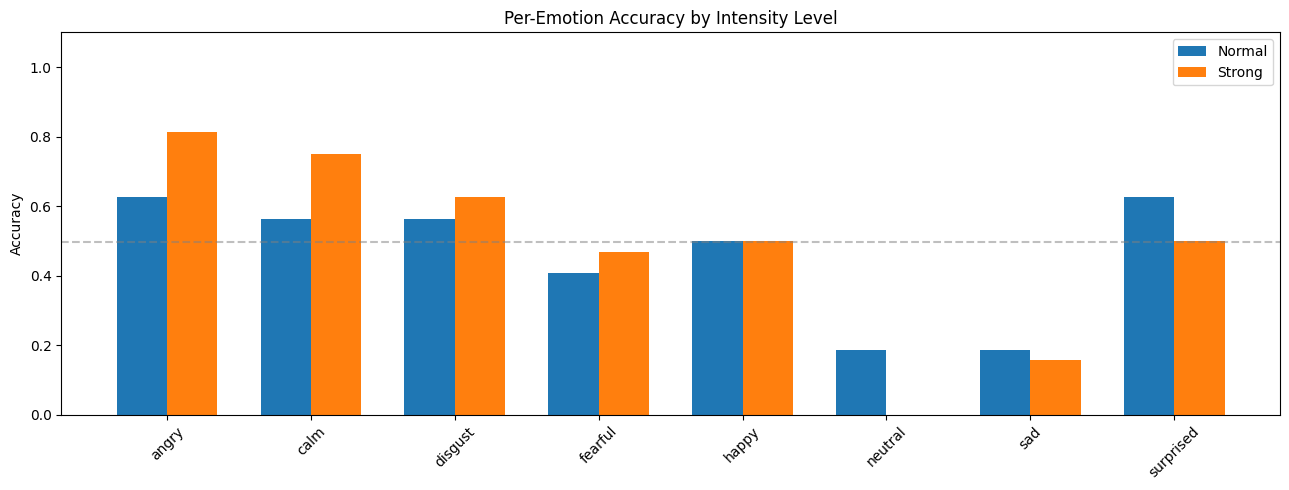

In [27]:
# Visualize accuracy per emotion, split by intensity
normal_mask = intensity_test == "normal"
results = []
for emotion in sorted(np.unique(y_test)):
    for intensity, mask in [("normal", normal_mask), ("strong", strong_mask)]:
        combined = (y_test == emotion) & mask
        if combined.sum() == 0:
            continue
        acc = accuracy_score(y_test[combined], test_preds[combined])
        results.append({"emotion": emotion, "intensity": intensity, "accuracy": acc, "n": combined.sum()})

results_df = pd.DataFrame(results)

fig, ax = plt.subplots(figsize=(13, 5))
width = 0.35
emotions = sorted(results_df["emotion"].unique())
x = np.arange(len(emotions))

for i, intensity in enumerate(["normal", "strong"]):
    subset = results_df[results_df["intensity"] == intensity].set_index("emotion")
    vals = [subset.loc[e, "accuracy"] if e in subset.index else 0 for e in emotions]
    ax.bar(x + i * width, vals, width, label=intensity.capitalize())

ax.set_xticks(x + width / 2)
ax.set_xticklabels(emotions, rotation=45)
ax.set_ylabel("Accuracy")
ax.set_ylim(0, 1.1)
ax.set_title("Per-Emotion Accuracy by Intensity Level")
ax.legend()
ax.axhline(y=accuracy_score(y_test, test_preds), color="gray", linestyle="--", alpha=0.5, label="Overall")
plt.tight_layout(); plt.show()

# 21. Emotion Grouping Experiment

The confusion matrix shows certain emotions get mixed up a lot — usually ones that
sound acoustically similar. What if we merge them into broader categories?

Groups (based on common confusions):
- **anger_disgust** — angry, disgust
- **sad_calm_neutral** — sad, calm, neutral
- **fear_surprise** — fearful, surprised
- **happy** — happy

Hypothesis: a 4-class problem should be easier than an 8-class one.


In [28]:
# Group emotions that overlap acoustically or were confused in the model
EMOTION_GROUPS = {
    "angry":     "anger_disgust",
    "disgust":   "anger_disgust",

    "sad":       "sad_calm_neutral",
    "calm":      "sad_calm_neutral",
    "neutral":   "sad_calm_neutral",

    "fearful":   "fear_surprise",
    "surprised": "fear_surprise",

    "happy":     "happy",
}

# Apply grouping to train and test labels
y_train_grouped = np.array([EMOTION_GROUPS[e] for e in y_train])
y_test_grouped  = np.array([EMOTION_GROUPS[e] for e in y_test])

print("Original classes:", sorted(np.unique(y_train)))
print("Grouped classes: ", sorted(np.unique(y_train_grouped)))

print("\nGroup sizes (test set):")
for g in sorted(np.unique(y_test_grouped)):
    print(f"  {g}: {(y_test_grouped == g).sum()} clips")

Original classes: ['angry', 'calm', 'disgust', 'fearful', 'happy', 'neutral', 'sad', 'surprised']
Grouped classes:  [np.str_('anger_disgust'), np.str_('fear_surprise'), np.str_('happy'), np.str_('sad_calm_neutral')]

Group sizes (test set):
  anger_disgust: 128 clips
  fear_surprise: 128 clips
  happy: 64 clips
  sad_calm_neutral: 160 clips


In [29]:
# Train a separate SVM on the grouped labels
grouped_model = make_pipeline(
    StandardScaler(),
    SVC(kernel="rbf", class_weight="balanced", C=10, gamma=0.001)
)
grouped_model.fit(X_train, y_train_grouped)
grouped_preds = grouped_model.predict(X_test)

grouped_acc  = accuracy_score(y_test_grouped, grouped_preds)
original_acc = accuracy_score(y_test, test_preds)

print("=== Grouped Emotion Results ===")
print(f"Accuracy: {grouped_acc:.4f}")
print(classification_report(y_test_grouped, grouped_preds))

print(f"\n--- Comparison ---")
print(f"8-class model:  {original_acc:.4f}")
print(f"3-group model:  {grouped_acc:.4f}")
print(f"Improvement:    {grouped_acc - original_acc:+.4f}")

=== Grouped Emotion Results ===
Accuracy: 0.5667
                  precision    recall  f1-score   support

   anger_disgust       0.57      0.72      0.64       128
   fear_surprise       0.59      0.45      0.51       128
           happy       0.28      0.48      0.36        64
sad_calm_neutral       0.81      0.57      0.67       160

        accuracy                           0.57       480
       macro avg       0.56      0.56      0.54       480
    weighted avg       0.62      0.57      0.58       480


--- Comparison ---
8-class model:  0.4979
3-group model:  0.5667
Improvement:    +0.0687


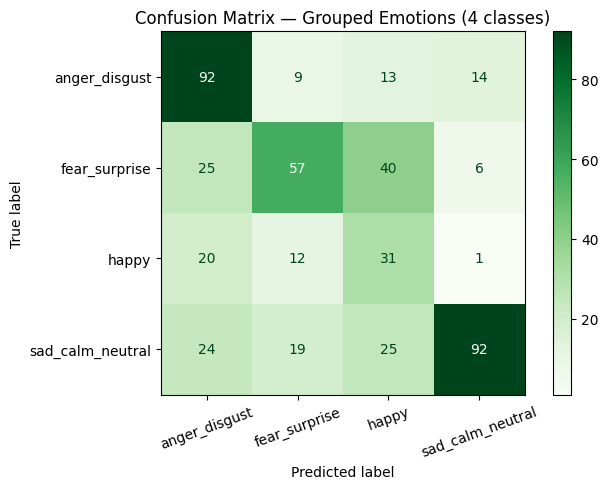

In [30]:
# Confusion matrix for the grouped model
group_labels = sorted(np.unique(y_test_grouped))
cm_grouped = confusion_matrix(y_test_grouped, grouped_preds, labels=group_labels)
disp = ConfusionMatrixDisplay(confusion_matrix=cm_grouped, display_labels=group_labels)
fig, ax = plt.subplots(figsize=(7, 5))
disp.plot(cmap="Greens", xticks_rotation=20, ax=ax)
plt.title("Confusion Matrix — Grouped Emotions (4 classes)")
plt.tight_layout(); plt.show()

# 22. Unsupervised Exploration — LDA + KMeans

Do emotions cluster naturally in audio feature space, even without labels?

1. **LDA** — projects ~345 features down to 2D, maximising class separation (uses labels for projection only)
2. **KMeans** — clusters that 2D space with no labels, then we compare to ground truth


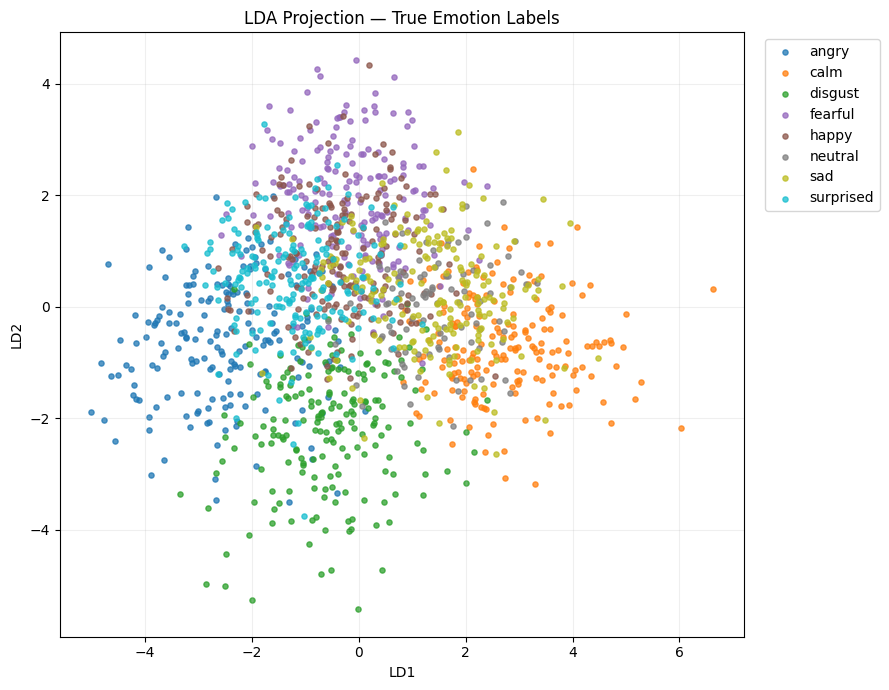

In [31]:
# Standardize first — LDA and KMeans are both sensitive to scale
scaler_unsup = StandardScaler()
X_scaled = scaler_unsup.fit_transform(X_features)

emotion_labels_all = df["emotion"].to_numpy()
emotion_order = sorted(np.unique(emotion_labels_all))
colors = plt.cm.tab10(np.linspace(0, 1, len(emotion_order)))

# LDA: supervised projection (uses labels to find best 2D plane)
lda = LinearDiscriminantAnalysis(n_components=2)
lda_coords = lda.fit_transform(X_scaled, emotion_labels_all)

lda_df = pd.DataFrame({"x": lda_coords[:, 0], "y": lda_coords[:, 1], "emotion": emotion_labels_all})

plt.figure(figsize=(9, 7))
for color, emotion in zip(colors, emotion_order):
    subset = lda_df[lda_df["emotion"] == emotion]
    plt.scatter(subset["x"], subset["y"], label=emotion, alpha=0.75, s=14, color=color)
plt.title("LDA Projection — True Emotion Labels")
plt.xlabel("LD1"); plt.ylabel("LD2")
plt.legend(bbox_to_anchor=(1.02, 1), loc="upper left")
plt.grid(alpha=0.2); plt.tight_layout(); plt.show()

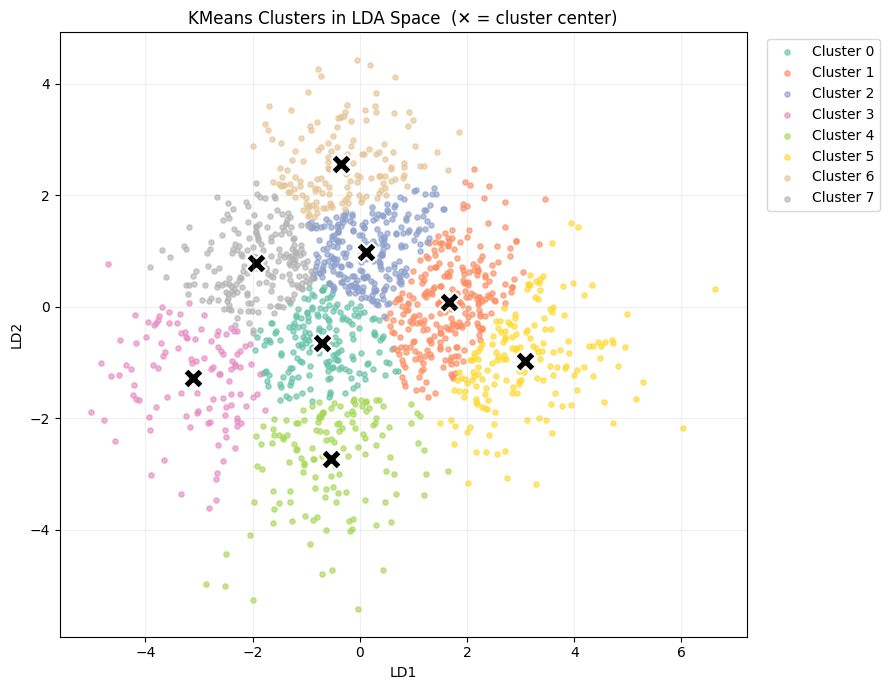

In [32]:
# KMeans — purely unsupervised, no labels used
kmeans = KMeans(n_clusters=len(emotion_order), random_state=SEED, n_init="auto")
cluster_ids = kmeans.fit_predict(lda_coords)
centers = kmeans.cluster_centers_

lda_df["cluster"] = cluster_ids.astype(str)
cluster_order  = sorted(lda_df["cluster"].unique(), key=int)
cluster_colors = plt.cm.Set2(np.linspace(0, 1, len(cluster_order)))

plt.figure(figsize=(9, 7))
for i, cluster in enumerate(cluster_order):
    subset = lda_df[lda_df["cluster"] == cluster]
    plt.scatter(subset["x"], subset["y"], label=f"Cluster {cluster}",
                alpha=0.65, s=14, color=cluster_colors[i])
    cx, cy = centers[i]
    plt.scatter(cx, cy, marker="X", s=220, color="black", edgecolor="white", linewidth=1.5)

plt.title("KMeans Clusters in LDA Space  (✕ = cluster center)")
plt.xlabel("LD1"); plt.ylabel("LD2")
plt.legend(bbox_to_anchor=(1.02, 1), loc="upper left")
plt.grid(alpha=0.2); plt.tight_layout(); plt.show()

**What does this tell us?**

Clusters look fairly clean in LDA space, but don't align perfectly with emotion labels —
KMeans groups by acoustic similarity, not human-labelled emotion.

Acoustically extreme emotions (**angry**, **calm**) form cleaner clusters.
Similar-sounding pairs (**neutral** / **calm**) bleed into each other, matching what we
saw in the SVM confusion matrix.

Bottom line: audio features carry real emotion signal, but supervised labels are still needed for clean boundaries.


# 24. Tina's Exploration: Does Gender Affect Emotion Recognition?

Does the model perform equally well for male and female speakers?  
In RAVDESS, gender is encoded in the actor ID: **odd = male, even = female**.

Let's slice the test-set predictions by gender and see if there's a gap.


Female Voices Accuracy: 0.5333 (240 samples)
Male Voices Accuracy:   0.4625 (240 samples)



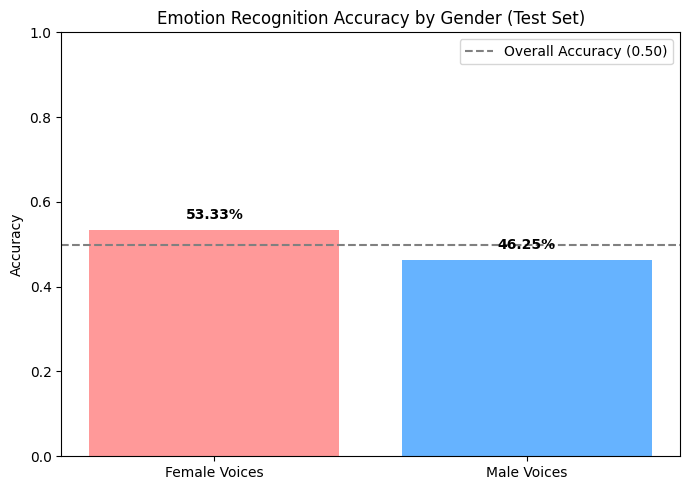

In [33]:
# Extract actor IDs for the test set
try:
    test_actors = test_df["actor_id"].to_numpy()
except NameError:
    test_actors = df["actor_id"].iloc[test_idx].to_numpy()

# Mask for female (even) and male (odd)
is_female = (test_actors % 2 == 0)
is_male   = (test_actors % 2 != 0)

# Calculate accuracy for each subgroup
acc_female = accuracy_score(y_test[is_female], test_preds[is_female])
acc_male   = accuracy_score(y_test[is_male], test_preds[is_male])

print(f"Female Voices Accuracy: {acc_female:.4f} ({is_female.sum()} samples)")
print(f"Male Voices Accuracy:   {acc_male:.4f} ({is_male.sum()} samples)\n")

# Visualize the difference
plt.figure(figsize=(7, 5))
bars = plt.bar(["Female Voices", "Male Voices"], [acc_female, acc_male], color=["#ff9999", "#66b3ff"])
plt.ylabel("Accuracy")
plt.title("Emotion Recognition Accuracy by Gender (Test Set)")
plt.ylim(0, 1.0)

# Add the overall accuracy as a baseline
overall_acc = accuracy_score(y_test, test_preds)
plt.axhline(overall_acc, color='gray', linestyle='--', label=f'Overall Accuracy ({overall_acc:.2f})')

# Add text labels on top of bars
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 0.02, f"{yval:.2%}", ha='center', va='bottom', fontweight='bold')

plt.legend()
plt.tight_layout()
plt.show()

**Why did the model do better on female voices?**

That's roughly an 11% accuracy gap. Female voices tend to have a wider, more dynamic
pitch range and higher acoustic brightness, giving the model clearer patterns to learn.
RAVDESS actresses also tend to use more expressive intonation.

**Takeaway:** The model has a measurable gender bias. In production we'd need gender-normalised
features or separate per-gender models to close the gap.


# Doing Cross Validation test for the model.

In [34]:
from sklearn.model_selection import GroupKFold, cross_val_score
import numpy as np

# We use the full unaugmented feature set and original labels for Cross Validation
X = X_features
y = df["emotion"].to_numpy()
groups = df["actor_id"].to_numpy()

# Initialize the same SVM pipeline used earlier
cv_model = make_pipeline(
    StandardScaler(),
    SVC(kernel="rbf", class_weight="balanced", C=1, gamma="scale")
)

# Use GroupKFold to ensure actors are not mixed between train and validation sets
gkf = GroupKFold(n_splits=5)

print("Running 5-fold cross-validation by actor...")
# n_jobs=-1 runs the cross-validation in parallel
cv_scores = cross_val_score(cv_model, X, y, cv=gkf, groups=groups, n_jobs=-1)

print(f"\nCross-validation scores: {cv_scores}")
print(f"Mean CV Accuracy: {np.mean(cv_scores):.4f} (+/- {np.std(cv_scores) * 2:.4f})")


Running 5-fold cross-validation by actor...

Cross-validation scores: [0.44333333 0.40333333 0.55       0.52       0.46666667]
Mean CV Accuracy: 0.4767 (+/- 0.1052)


Generating cross-validation predictions...


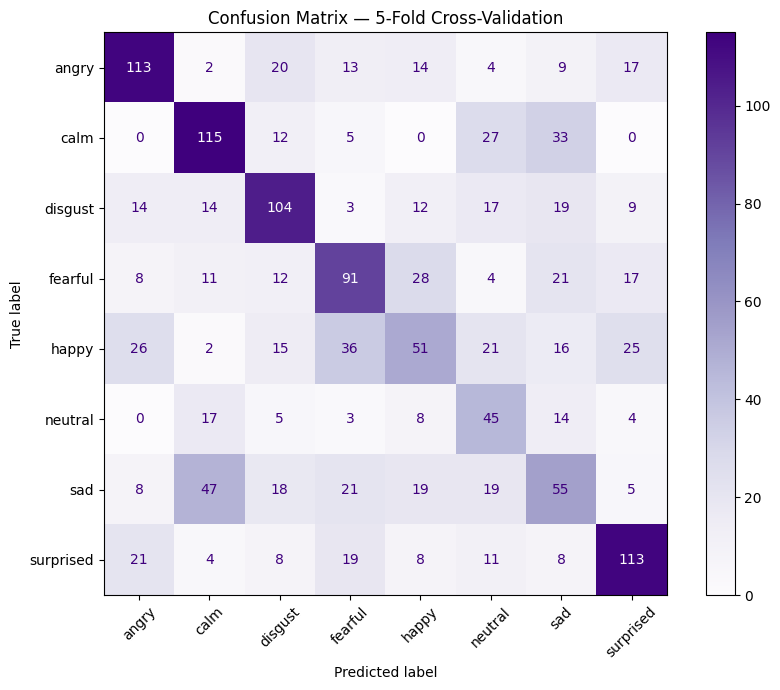

In [35]:
from sklearn.model_selection import cross_val_predict
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

print("Generating cross-validation predictions...")
# cross_val_predict generates out-of-fold predictions for every data point
cv_preds = cross_val_predict(cv_model, X, y, cv=gkf, groups=groups, n_jobs=-1)

# Compute and plot the confusion matrix for the CV predictions
cm_cv = confusion_matrix(y, cv_preds, labels=sorted(np.unique(y)))
disp_cv = ConfusionMatrixDisplay(confusion_matrix=cm_cv, display_labels=sorted(np.unique(y)))

fig, ax = plt.subplots(figsize=(9, 7))
disp_cv.plot(cmap="Purples", xticks_rotation=45, ax=ax)
plt.title("Confusion Matrix — 5-Fold Cross-Validation")
plt.tight_layout()
plt.show()